# HealthLens: District Health Baseline & Monitoring Framework
### NFHS-4 vs NFHS-5 — Visakhapatnam, Andhra Pradesh

**Scope:** A data analytics portfolio project comparing two rounds of India's National Family Health Survey (NFHS-4, 2015-16 and NFHS-5, 2019-21) for one district to identify which health indicators are improving, declining, or lack historical data — and therefore deserve continued monitoring. **It does not claim or test that any specific factor caused the observed changes.**


## 1. Introduction

Public health indicators rarely move for a single reason, so before crediting any program or infrastructure project with an "improvement," there needs to be a clear baseline: what did the numbers look like before, and how were they already trending? This notebook builds that baseline from two rounds of India's district-level NFHS survey, ranks indicators by direction and magnitude of change, and flags which ones most need continued monitoring.

**This is descriptive, not causal, analysis** — no confounders are controlled for and no statistical inference is performed. The goal is to describe change and prioritize what to watch next.


## 2. Imports & Configuration
All libraries are part of Google Colab's default environment — no installs needed. A consistent pastel plotting theme is set once, globally, for the whole notebook.


In [1]:

# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Utilities ---
import textwrap
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# --- Global display settings ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- Global plotting theme (pastel, professional, consistent) ---
PASTEL_PALETTE = ["#8ecae6", "#ffb4a2", "#b8bedd", "#95d5b2",
                  "#ffd6a5", "#cdb4db", "#f4a6a6", "#a0ced9"]

sns.set_theme(
    style="whitegrid",
    palette=PASTEL_PALETTE,
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#4a4a4a",
        "axes.labelcolor": "#2b2b2b",
        "text.color": "#2b2b2b",
        "xtick.color": "#2b2b2b",
        "ytick.color": "#2b2b2b",
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "grid.color": "#e6e6e6",
        "grid.linewidth": 0.6,
        "axes.grid": True,
    },
)

COLOR_IMPROVE = "#6fb98f"   # muted pastel green — favourable change
COLOR_DECLINE = "#e88d8d"   # muted pastel red   — unfavourable change
COLOR_NEUTRAL = "#8ecae6"   # pastel blue        — neutral / mixed

# --- Global spacing / layout defaults (prevents overlap notebook-wide) ---
plt.rcParams.update({
    "axes.titlepad": 14,
    "axes.labelpad": 10,
    "legend.frameon": False,
    "savefig.dpi": 150,
})

def wrap_label(text: str, width: int = 26) -> str:
    """Wrap a long label onto multiple lines instead of truncating it."""
    return "\n".join(textwrap.wrap(str(text), width=width))

def style_ax(ax, grid_axis="both"):
    """Apply the shared pastel/report look to a single axis: strip
    unnecessary borders, keep gridlines subtle."""
    sns.despine(ax=ax)
    ax.grid(axis=grid_axis, color="#e6e6e6", linewidth=0.6, alpha=0.9)
    ax.set_axisbelow(True)
    return ax

print("Libraries imported and plotting theme configured successfully.")


Libraries imported and plotting theme configured successfully.


## 3. Data Loading

### Data source
Loaded directly from a public, versioned CSV on GitHub (no upload needed) — [`NFHS-5-Districts.csv`](https://github.com/pratapvardhan/NFHS-5), compiled from official IIPS NFHS-4/NFHS-5 district factsheets (CC BY 4.0). Covers 341 districts with paired NFHS-4 and NFHS-5 values per indicator.

### District configuration
Only the two variables below need to change to re-run this notebook for a different district.


In [2]:

# ============================================================
# DISTRICT CONFIGURATION — change these two lines to re-run
# this entire notebook for any of the 341 districts covered.
# ============================================================
TARGET_STATE = "Andhra Pradesh"
TARGET_DISTRICT = "Visakhapatnam"

DATA_URL = "https://raw.githubusercontent.com/pratapvardhan/NFHS-5/master/NFHS-5-Districts.csv"

raw_df = pd.read_csv(DATA_URL)

print(f"Loaded dataset from source: {DATA_URL}")
print(f"Full dataset shape (all districts, all indicators): {raw_df.shape}")


Loaded dataset from source: https://raw.githubusercontent.com/pratapvardhan/NFHS-5/master/NFHS-5-Districts.csv
Full dataset shape (all districts, all indicators): (35464, 8)


In [3]:

print("Column names:")
print(list(raw_df.columns))
print()
print("Preview of raw data (first 5 rows):")
raw_df.head()


Column names:
['State', 'State-Code', 'District', 'Indicator', 'NFHS-5', 'NFHS-4', 'NFHS-5-note', 'NFHS-4-note']

Preview of raw data (first 5 rows):


,State,State-Code,District,Indicator,NFHS-5,NFHS-4,NFHS-5-note,NFHS-4-note
0,Andaman and Nicobar Island,AN,Nicobar,1. Female population age 6 years and above who...,78.00,77.20,NaN,NaN
1,Andaman and Nicobar Island,AN,Nicobar,2. Population below age 15 years (%),23.00,25.40,NaN,NaN
2,Andaman and Nicobar Island,AN,Nicobar,3. Sex ratio of the total population (females ...,973.00,957.00,NaN,NaN
3,Andaman and Nicobar Island,AN,Nicobar,4. Sex ratio at birth for children born in the...,927.00,"1,060.00",NaN,NaN
4,Andaman and Nicobar Island,AN,Nicobar,5. Children under age 5 years whose birth was ...,98.00,99.30,NaN,NaN


In [4]:

missing_summary = raw_df.isna().sum().to_frame(name="missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(raw_df) * 100).round(2)
missing_summary


,missing_count,missing_pct
State,0,0.00
State-Code,0,0.00
District,0,0.00
Indicator,0,0.00
NFHS-5,2018,5.69
NFHS-4,16427,46.32
NFHS-5-note,30728,86.65
NFHS-4-note,32369,91.27


In [5]:

district_df = raw_df[
    (raw_df["State"] == TARGET_STATE) & (raw_df["District"] == TARGET_DISTRICT)
].copy()

if district_df.empty:
    available = sorted(raw_df.loc[raw_df["State"] == TARGET_STATE, "District"].unique())
    raise ValueError(
        f"No rows found for District='{TARGET_DISTRICT}' in State='{TARGET_STATE}'. "
        f"Districts available for this state: {available}"
    )

print(f"Rows for {TARGET_DISTRICT}, {TARGET_STATE}: {district_df.shape[0]}")
print(f"Missing values in this district's slice (NFHS-5 / NFHS-4 columns):")
print(district_df[["NFHS-5", "NFHS-4"]].isna().sum())
district_df.head(10)


Rows for Visakhapatnam, Andhra Pradesh: 104
Missing values in this district's slice (NFHS-5 / NFHS-4 columns):
NFHS-5     8
NFHS-4    36
dtype: int64


,State,State-Code,District,Indicator,NFHS-5,NFHS-4,NFHS-5-note,NFHS-4-note
1248,Andhra Pradesh,AP,Visakhapatnam,1. Female population age 6 years and above who...,66.80,61.30,NaN,NaN
1249,Andhra Pradesh,AP,Visakhapatnam,2. Population below age 15 years (%),21.40,23.30,NaN,NaN
1250,Andhra Pradesh,AP,Visakhapatnam,3. Sex ratio of the total population (females ...,"1,066.00","1,047.00",NaN,NaN
1251,Andhra Pradesh,AP,Visakhapatnam,4. Sex ratio at birth for children born in the...,974.00,"1,097.00",NaN,NaN
1252,Andhra Pradesh,AP,Visakhapatnam,5. Children under age 5 years whose birth was ...,90.50,84.50,NaN,NaN
1253,Andhra Pradesh,AP,Visakhapatnam,6. Deaths in the last 3 years registered with ...,71.30,NaN,NaN,NaN
1254,Andhra Pradesh,AP,Visakhapatnam,7. Population living in households with electr...,99.60,99.10,NaN,NaN
1255,Andhra Pradesh,AP,Visakhapatnam,8. Population living in households with an imp...,91.80,89.30,NaN,NaN
1256,Andhra Pradesh,AP,Visakhapatnam,9. Population living in households that use an...,77.80,54.70,NaN,NaN
1257,Andhra Pradesh,AP,Visakhapatnam,10. Households using clean fuel for cooking3 (%),72.90,56.10,NaN,NaN


## 4. Data Cleaning

### 4.1 Duplicate indicator rows
Indicators 86-88 and 92-94 are exact duplicates of 89-91 and 95-97 — a known artifact of how blood sugar/BP readings were split by sex in the source PDFs, with the sex label lost in conversion. **Decision: keep the first occurrence, drop the duplicate.**


In [6]:

# --- 4.1 Remove exact duplicate indicator labels (data-quality issue explained above) ---
before_dedup = district_df.shape[0]
district_df = district_df.drop_duplicates(subset=["Indicator"], keep="first").copy()
after_dedup = district_df.shape[0]

print(f"Rows before de-duplication: {before_dedup}")
print(f"Rows after de-duplication:  {after_dedup}")
print(f"Duplicate indicator rows removed: {before_dedup - after_dedup}")


Rows before de-duplication: 104
Rows after de-duplication:  104
Duplicate indicator rows removed: 0


### 4.2 Indicator numbers & readable labels
Each indicator's official NFHS question number is extracted for sorting, and a short, chart-friendly label is built from the full indicator text.


In [7]:

import re

def extract_indicator_number(text: str) -> int:
    """Pull the leading question number off an NFHS indicator string."""
    match = re.match(r"\s*(\d+)\.", text)
    return int(match.group(1)) if match else np.nan

def build_short_label(text: str, max_len: int = 55) -> str:
    """Produce a compact, chart-friendly label from the full indicator text."""
    # Drop the leading "N. " numbering
    label = re.sub(r"^\s*\d+\.\s*", "", text)
    # Drop footnote markers like "16, 17" or standalone superscript-style digits
    # that trail immediately before "(%)" or at the end of the string.
    label = re.sub(r"\d+(,\s*\d+)*\s*(?=\(%\)|\(Rs\.\)|$)", "", label)
    label = label.replace("  ", " ").strip()
    if len(label) > max_len:
        label = textwrap.shorten(label, width=max_len, placeholder="…")
    return label

district_df["indicator_number"] = district_df["Indicator"].apply(extract_indicator_number)
district_df["indicator_full_label"] = district_df["Indicator"].str.strip()
district_df["indicator_short_label"] = district_df["Indicator"].apply(build_short_label)

district_df[["indicator_number", "indicator_short_label", "NFHS-4", "NFHS-5"]].head(8)


,indicator_number,indicator_short_label,NFHS-4,NFHS-5
1248,1,Female population age 6 years and above who ever…,61.30,66.80
1249,2,Population below age 15 years (%),23.30,21.40
1250,3,Sex ratio of the total population (females per...,"1,047.00","1,066.00"
1251,4,Sex ratio at birth for children born in the la...,"1,097.00",974.00
1252,5,Children under age 5 years whose birth was reg...,84.50,90.50
1253,6,Deaths in the last 3 years registered with the...,NaN,71.30
1254,7,Population living in households with electrici...,99.10,99.60
1255,8,Population living in households with an improved…,89.30,91.80


### 4.3 Curated indicator subset
NFHS-5 publishes 104 district indicators; only those measuring a direct health outcome, service-access outcome, or disease-burden marker relevant to infrastructure-linked public health are kept (demographics, marriage/fertility timing, family-planning method choice, and non-percentage indicators are excluded). This leaves a curated set organized into 9 health themes.


In [8]:

# ============================================================
# Curated indicator numbers, organised by health theme.
# Editing this dictionary is the ONLY thing required to change
# which indicators this notebook analyses.
# ============================================================
THEME_INDICATOR_MAP = {
    "Infrastructure & Environmental Access": [7, 8, 9, 10, 11],
    "Respiratory & Waterborne Illness": [61, 62, 63, 64, 65, 66],
    "Maternal & Newborn Care Access": [32, 33, 37, 42, 44, 45],
    "Child Immunization Coverage": [49, 51, 52, 53, 54],
    "Child Nutrition & Growth": [73, 74, 75, 76, 77],
    "Anaemia (Women & Children)": [81, 82, 83, 84, 85],
    "Women's Nutritional Status (BMI)": [78, 79, 80],
    "Lifestyle-Related NCDs & Screening": [86, 87, 88, 92, 93, 94, 98, 99, 100],
    "Substance Use": [101, 102, 103, 104],
}

curated_indicator_numbers = sorted(
    {num for indicators in THEME_INDICATOR_MAP.values() for num in indicators}
)

print(f"Total curated indicators selected: {len(curated_indicator_numbers)} of {district_df['indicator_number'].nunique()} available")

curated_df = district_df[district_df["indicator_number"].isin(curated_indicator_numbers)].copy()
print(f"Curated dataframe shape: {curated_df.shape}")

# Sanity check: every configured indicator number was actually found in the data
missing_from_source = set(curated_indicator_numbers) - set(curated_df["indicator_number"])
if missing_from_source:
    raise ValueError(f"These configured indicator numbers were not found in the source data: {missing_from_source}")
print("All configured indicator numbers were found in the source data.")


Total curated indicators selected: 48 of 104 available
Curated dataframe shape: (48, 11)
All configured indicator numbers were found in the source data.


### 4.4 Missing NFHS-4 values
Some indicators (all of "Lifestyle-Related NCDs & Screening" and "Substance Use") have no NFHS-4 value because those questions are new to NFHS-5 — not a data gap. A `has_baseline` flag marks these explicitly rather than imputing a value.


In [9]:

curated_df["has_baseline"] = curated_df["NFHS-4"].notna() & curated_df["NFHS-5"].notna()

no_baseline_count = (~curated_df["has_baseline"]).sum()
print(f"Curated indicators with a usable NFHS-4 → NFHS-5 baseline comparison: {curated_df['has_baseline'].sum()}")
print(f"Curated indicators with NO historical baseline (NFHS-4 missing):      {no_baseline_count}")

print("\nIndicators lacking a baseline:")
curated_df.loc[~curated_df["has_baseline"], ["indicator_number", "indicator_short_label"]]


Curated indicators with a usable NFHS-4 → NFHS-5 baseline comparison: 29
Curated indicators with NO historical baseline (NFHS-4 missing):      19

Indicators lacking a baseline:


,indicator_number,indicator_short_label
1309,62,Children with diarrhoea in the 2 weeks precedi...
1310,63,Children with diarrhoea in the 2 weeks precedi...
1311,64,Children with diarrhoea in the 2 weeks precedi...
1313,66,Children with fever or symptoms of ARI in the ...
1327,80,Women who have high risk waist-to-hip ratio (≥...
1330,83,Pregnant women age 15-49 years who are anaemic...
1333,86,Blood sugar level - high (141-160 mg/dl)(%)
1334,87,Blood sugar level - very high (>160 mg/dl)(%)
1335,88,Blood sugar level - high or very high (>140 mg...
1339,92,Mildly elevated blood pressure (Systolic 140-1...


In [10]:

# --- 4.5 Final tidy structure, ready for analysis and plotting ---
theme_lookup = {
    num: theme
    for theme, nums in THEME_INDICATOR_MAP.items()
    for num in nums
}
curated_df["theme"] = curated_df["indicator_number"].map(theme_lookup)

clean_df = curated_df[[
    "indicator_number", "indicator_short_label", "indicator_full_label",
    "theme", "NFHS-4", "NFHS-5", "has_baseline"
]].sort_values("indicator_number").reset_index(drop=True)

clean_df.rename(columns={"NFHS-4": "nfhs4_value", "NFHS-5": "nfhs5_value"}, inplace=True)

print(f"Final cleaned analysis table: {clean_df.shape[0]} indicators x {clean_df.shape[1]} columns")
clean_df.head(10)


Final cleaned analysis table: 48 indicators x 7 columns


,indicator_number,indicator_short_label,indicator_full_label,theme,nfhs4_value,nfhs5_value,has_baseline
0,7,Population living in households with electrici...,7. Population living in households with electr...,Infrastructure & Environmental Access,99.10,99.60,True
1,8,Population living in households with an improved…,8. Population living in households with an imp...,Infrastructure & Environmental Access,89.30,91.80,True
2,9,Population living in households that use an im...,9. Population living in households that use an...,Infrastructure & Environmental Access,54.70,77.80,True
3,10,Households using clean fuel for cooking(%),10. Households using clean fuel for cooking3 (%),Infrastructure & Environmental Access,56.10,72.90,True
4,11,Households using iodized salt (%),11. Households using iodized salt (%),Infrastructure & Environmental Access,90.40,82.20,True
5,32,Mothers who had an antenatal check-up in the f...,32. Mothers who had an antenatal check-up in t...,Maternal & Newborn Care Access,77.90,79.40,True
6,33,Mothers who had at least 4 antenatal care visi...,33. Mothers who had at least 4 antenatal care ...,Maternal & Newborn Care Access,81.80,58.60,True
7,37,Registered pregnancies for which the mother re...,37. Registered pregnancies for which the mothe...,Maternal & Newborn Care Access,94.00,97.00,True
8,42,Institutional births (%),42. Institutional births (%),Maternal & Newborn Care Access,84.90,95.30,True
9,44,Home births that were conducted by skilled hea...,44. Home births that were conducted by skilled...,Maternal & Newborn Care Access,1.80,0.00,True


## 5. Exploratory Data Analysis
Before ranking changes, we look at the shape of the cleaned data: how many indicators have both survey rounds available, and how availability breaks down by theme.


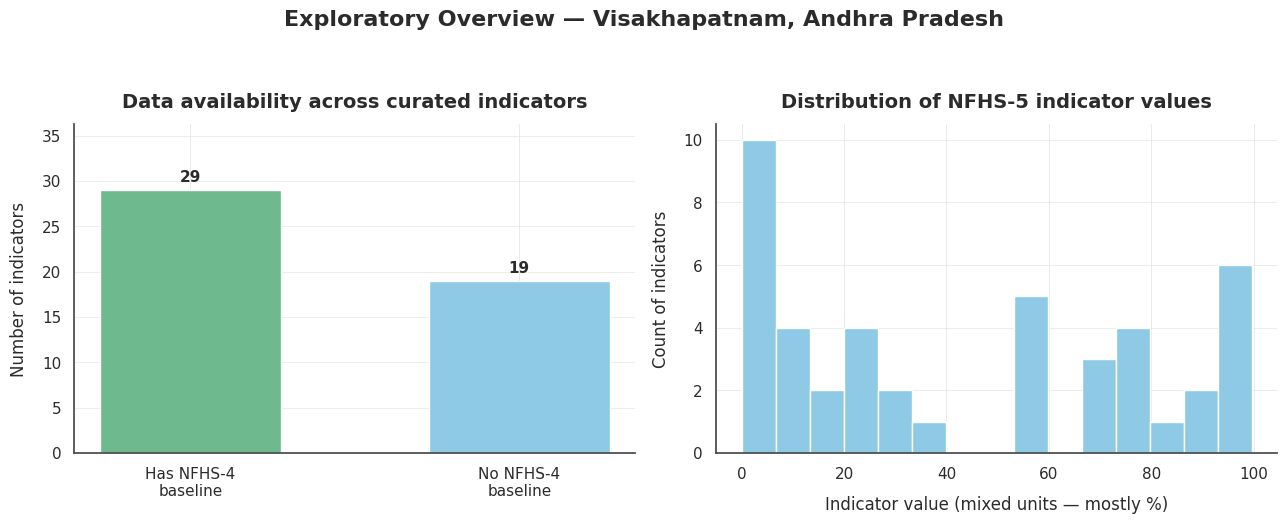

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: baseline availability ---
availability_counts = clean_df["has_baseline"].value_counts().reindex([True, False], fill_value=0)
bars = axes[0].bar(
    ["Has NFHS-4\nbaseline", "No NFHS-4\nbaseline"],
    availability_counts.values,
    color=[COLOR_IMPROVE, COLOR_NEUTRAL],
    width=0.55,
)
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height),
                      xytext=(0, 4), textcoords="offset points",
                      ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Data availability across curated indicators", pad=12)
axes[0].set_ylabel("Number of indicators")
axes[0].set_ylim(0, availability_counts.max() * 1.25)
style_ax(axes[0], grid_axis="y")

# --- Panel 2: distribution of NFHS-5 values (most recent round) ---
axes[1].hist(clean_df["nfhs5_value"].dropna(), bins=15, color=COLOR_NEUTRAL, edgecolor="white")
axes[1].set_title("Distribution of NFHS-5 indicator values", pad=12)
axes[1].set_xlabel("Indicator value (mixed units — mostly %)")
axes[1].set_ylabel("Count of indicators")
style_ax(axes[1], grid_axis="y")

fig.suptitle(f"Exploratory Overview — {TARGET_DISTRICT}, {TARGET_STATE}", fontsize=16, fontweight="bold", y=1.04)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


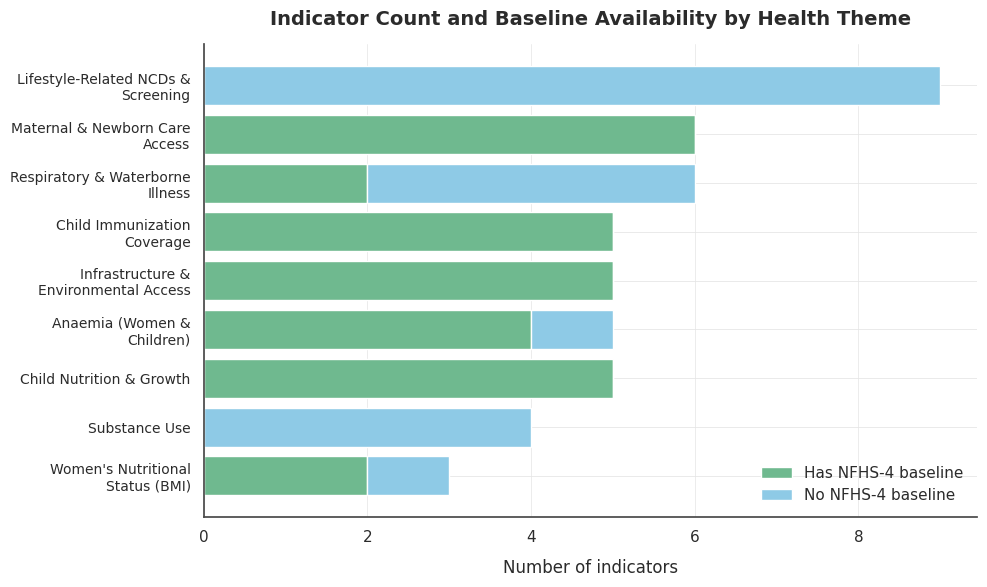

In [12]:

theme_availability = (
    clean_df.groupby("theme")["has_baseline"]
    .agg(total="count", with_baseline="sum")
    .assign(without_baseline=lambda d: d["total"] - d["with_baseline"])
    .sort_values("total")
)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(theme_availability))
ax.barh(y_pos, theme_availability["with_baseline"], color=COLOR_IMPROVE, label="Has NFHS-4 baseline")
ax.barh(y_pos, theme_availability["without_baseline"], left=theme_availability["with_baseline"],
        color=COLOR_NEUTRAL, label="No NFHS-4 baseline")
ax.set_yticks(y_pos)
ax.set_yticklabels([wrap_label(t, 24) for t in theme_availability.index], fontsize=10)
ax.set_xlabel("Number of indicators")
ax.set_title("Indicator Count and Baseline Availability by Health Theme", pad=14)
ax.legend(loc="lower right")
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


**Interpretation:** Most curated indicators have a usable before/after comparison, but "Lifestyle-Related NCDs & Screening" and "Substance Use" have **no NFHS-4 baseline at all** — every indicator in those themes is new to NFHS-5. That's the clearest data gap here, and the strongest argument for starting to track them now.


In [13]:

theme_summary = (
    clean_df.groupby("theme")
    .agg(
        num_indicators=("indicator_number", "count"),
        num_with_baseline=("has_baseline", "sum"),
        avg_nfhs5_value=("nfhs5_value", "mean"),
    )
    .round(1)
    .sort_values("num_indicators", ascending=False)
)
theme_summary


,num_indicators,num_with_baseline,avg_nfhs5_value
theme,,,
Lifestyle-Related NCDs & Screening,9,0,8.90
Respiratory & Waterborne Illness,6,2,27.50
Maternal & Newborn Care Access,6,6,70.80
Anaemia (Women & Children),5,4,62.00
Child Immunization Coverage,5,5,87.30
Infrastructure & Environmental Access,5,5,84.90
Child Nutrition & Growth,5,5,20.40
Substance Use,4,0,15.20
Women's Nutritional Status (BMI),3,2,33.10


## 6. Automated Change Table
For every indicator with a usable baseline: **absolute change** = NFHS-5 − NFHS-4, **percentage change** = absolute change / NFHS-4 × 100, and a **trend** label. Since "up" is favourable for some indicators (e.g. immunization) and unfavourable for others (e.g. anaemia), a `FAVOURABLE_DIRECTION` lookup maps each indicator to its desired direction so trends read as "Improved" / "Declined" correctly.


In [14]:

# ============================================================
# For each indicator, is an INCREASE the favourable direction?
# True  -> higher value is better (e.g. access, coverage rates)
# False -> lower value is better (e.g. disease burden, risk factors)
# ============================================================
FAVOURABLE_DIRECTION_UP = {
    7: True, 8: True, 9: True, 10: True, 11: True,                  # infrastructure access
    61: False, 62: True, 63: True, 64: True, 65: False, 66: True,   # illness prevalence (down=good) / care-seeking (up=good)
    32: True, 33: True, 37: True, 42: True, 44: True, 45: True,     # maternal & newborn care access
    49: True, 51: True, 52: True, 53: True, 54: True,               # immunization coverage
    73: False, 74: False, 75: False, 76: False, 77: False,          # child nutrition (all "% affected" -> down=good)
    81: False, 82: False, 83: False, 84: False, 85: False,          # anaemia prevalence
    78: False, 79: False, 80: False,                                # BMI / waist-hip risk
    86: False, 87: False, 88: False, 92: False, 93: False, 94: False,  # blood sugar / BP risk
    98: True, 99: True, 100: True,                                  # cancer screening uptake -> up=good
    101: False, 102: False, 103: False, 104: False,                 # tobacco / alcohol use
}

def classify_trend(row):
    if not row["has_baseline"]:
        return "No baseline"
    if row["absolute_change"] == 0:
        return "No change"
    favourable_up = FAVOURABLE_DIRECTION_UP.get(row["indicator_number"])
    moved_up = row["absolute_change"] > 0
    if favourable_up is None:
        return "Increased" if moved_up else "Decreased"
    is_improvement = moved_up == favourable_up
    return "Improved" if is_improvement else "Declined"

change_df = clean_df.copy()
change_df["absolute_change"] = change_df["nfhs5_value"] - change_df["nfhs4_value"]
change_df["percentage_change"] = np.where(
    change_df["has_baseline"] & (change_df["nfhs4_value"] != 0),
    (change_df["absolute_change"] / change_df["nfhs4_value"]) * 100,
    np.nan,
)
change_df["trend"] = change_df.apply(classify_trend, axis=1)

analysis_table = change_df[[
    "indicator_number", "indicator_short_label", "theme",
    "nfhs4_value", "nfhs5_value", "absolute_change", "percentage_change", "trend"
]].round(2).sort_values("indicator_number").reset_index(drop=True)

print(f"Analysis table generated: {analysis_table.shape[0]} rows")
analysis_table.head(12)


Analysis table generated: 48 rows


,indicator_number,indicator_short_label,theme,nfhs4_value,nfhs5_value,absolute_change,percentage_change,trend
0,7,Population living in households with electrici...,Infrastructure & Environmental Access,99.10,99.60,0.50,0.50,Improved
1,8,Population living in households with an improved…,Infrastructure & Environmental Access,89.30,91.80,2.50,2.80,Improved
2,9,Population living in households that use an im...,Infrastructure & Environmental Access,54.70,77.80,23.10,42.23,Improved
3,10,Households using clean fuel for cooking(%),Infrastructure & Environmental Access,56.10,72.90,16.80,29.95,Improved
4,11,Households using iodized salt (%),Infrastructure & Environmental Access,90.40,82.20,-8.20,-9.07,Declined
5,32,Mothers who had an antenatal check-up in the f...,Maternal & Newborn Care Access,77.90,79.40,1.50,1.93,Improved
6,33,Mothers who had at least 4 antenatal care visi...,Maternal & Newborn Care Access,81.80,58.60,-23.20,-28.36,Declined
7,37,Registered pregnancies for which the mother re...,Maternal & Newborn Care Access,94.00,97.00,3.00,3.19,Improved
8,42,Institutional births (%),Maternal & Newborn Care Access,84.90,95.30,10.40,12.25,Improved
9,44,Home births that were conducted by skilled hea...,Maternal & Newborn Care Access,1.80,0.00,-1.80,-100.00,Declined


## 7. Automatically Generated Insights
Rankings computed directly from `analysis_table` — nothing below is manually written.


In [15]:

with_baseline = analysis_table[analysis_table["trend"] != "No baseline"].copy()

def top_n_by(df, column, n, ascending=False, favourable_only=None):
    subset = df.copy()
    if favourable_only == "improved":
        subset = subset[subset["trend"] == "Improved"]
    elif favourable_only == "declined":
        subset = subset[subset["trend"] == "Declined"]
    return subset.sort_values(column, ascending=ascending).head(n)[
        ["indicator_short_label", "theme", "nfhs4_value", "nfhs5_value", "absolute_change", "percentage_change", "trend"]
    ].reset_index(drop=True)

top5_improvements = top_n_by(with_baseline, "absolute_change", 5, ascending=False, favourable_only="improved")
top5_declines = top_n_by(with_baseline, "absolute_change", 5, ascending=True, favourable_only="declined")
top5_pct_increase = top_n_by(with_baseline, "percentage_change", 5, ascending=False)
top5_pct_decrease = top_n_by(with_baseline, "percentage_change", 5, ascending=True)
no_baseline_indicators = analysis_table[analysis_table["trend"] == "No baseline"][
    ["indicator_short_label", "theme"]
].reset_index(drop=True)


In [16]:
print(f"=== INDICATORS WITH NO HISTORICAL BASELINE ({len(no_baseline_indicators)}) ===")
display(no_baseline_indicators)

=== INDICATORS WITH NO HISTORICAL BASELINE (19) ===


,indicator_short_label,theme
0,Children with diarrhoea in the 2 weeks precedi...,Respiratory & Waterborne Illness
1,Children with diarrhoea in the 2 weeks precedi...,Respiratory & Waterborne Illness
2,Children with diarrhoea in the 2 weeks precedi...,Respiratory & Waterborne Illness
3,Children with fever or symptoms of ARI in the ...,Respiratory & Waterborne Illness
4,Women who have high risk waist-to-hip ratio (≥...,Women's Nutritional Status (BMI)
5,Pregnant women age 15-49 years who are anaemic...,Anaemia (Women & Children)
6,Blood sugar level - high (141-160 mg/dl)(%),Lifestyle-Related NCDs & Screening
7,Blood sugar level - very high (>160 mg/dl)(%),Lifestyle-Related NCDs & Screening
8,Blood sugar level - high or very high (>140 mg...,Lifestyle-Related NCDs & Screening
9,Mildly elevated blood pressure (Systolic 140-1...,Lifestyle-Related NCDs & Screening


## 8. Health Monitoring Priority Score
A simple, transparent heuristic — not a validated statistical index — ranking indicators by how urgently they warrant monitoring. It combines three equally-weighted 0-1 components: **magnitude of change**, a **direction penalty** (unfavourable moves score higher), and a **theme importance weight** (a documented judgment call). Indicators with no historical baseline score highest by construction, since they have zero monitoring history to draw on.


In [17]:

THEME_IMPORTANCE_WEIGHT = {
    "Infrastructure & Environmental Access": 1.1,
    "Respiratory & Waterborne Illness": 1.5,
    "Maternal & Newborn Care Access": 1.2,
    "Child Immunization Coverage": 1.2,
    "Child Nutrition & Growth": 1.3,
    "Anaemia (Women & Children)": 1.3,
    "Women's Nutritional Status (BMI)": 1.2,
    "Lifestyle-Related NCDs & Screening": 1.5,
    "Substance Use": 1.4,
}

priority_df = analysis_table.copy()

# --- Component 1: magnitude of change (0-1 scaled), using |% change| where available ---
# Robust-scaled: clipped at the 95th percentile so a single extreme outlier
# (e.g. a 646% change) no longer squashes every other indicator's score toward 0.
abs_pct = priority_df["percentage_change"].abs()
p95 = abs_pct.quantile(0.95)
priority_df["magnitude_score"] = (abs_pct.clip(upper=p95) / p95).fillna(0)

# --- Component 2: direction penalty (favourable=0.3, declined=1.0, neutral/no-baseline=0.6) ---
direction_score_map = {"Improved": 0.3, "Declined": 1.0, "Increased": 0.6, "Decreased": 0.6, "No change": 0.5, "No baseline": 0.6}
priority_df["direction_score"] = priority_df["trend"].map(direction_score_map)

# --- Component 3: theme importance weight, rescaled 0-1 ---
priority_df["importance_raw"] = priority_df["theme"].map(THEME_IMPORTANCE_WEIGHT)
min_w, max_w = priority_df["importance_raw"].min(), priority_df["importance_raw"].max()
priority_df["importance_score"] = (priority_df["importance_raw"] - min_w) / (max_w - min_w)

# --- Combine (simple average of the three 0-1 components) ---
priority_df["priority_score"] = (
    priority_df["magnitude_score"] + priority_df["direction_score"] + priority_df["importance_score"]
) / 3

# Indicators with no historical baseline still rank as top monitoring priority
# BY CONSTRUCTION (methodology unchanged) — but are no longer all clipped to an
# identical 1.0. Theme importance now differentiates them within a 0.90-1.00 band,
# so relative ranking is preserved and visible instead of a flat line of 1s.
no_baseline_mask = priority_df["trend"] == "No baseline"
priority_df.loc[no_baseline_mask, "priority_score"] = (
    0.90 + 0.10 * priority_df.loc[no_baseline_mask, "importance_score"]
)

priority_df["priority_score"] = priority_df["priority_score"].round(3)

health_monitoring_priority_table = priority_df.sort_values("priority_score", ascending=False)[
    ["indicator_short_label", "theme", "trend", "percentage_change", "priority_score"]
].reset_index(drop=True)

print("Top 15 indicators by Health Monitoring Priority Score:")
health_monitoring_priority_table.head(15)


Top 15 indicators by Health Monitoring Priority Score:


,indicator_short_label,theme,trend,percentage_change,priority_score
0,Ever undergone an oral cavity examination for ...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
1,Mildly elevated blood pressure (Systolic 140-1...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
2,Blood sugar level - high or very high (>140 mg...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
3,Blood sugar level - high (141-160 mg/dl)(%),Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
4,Moderately or severely elevated blood pressure…,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
5,Ever undergone a breast examination for breast...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
6,Ever undergone a screening test for cervical c...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
7,Elevated blood pressure (Systolic ≥140 mm of H...,Lifestyle-Related NCDs & Screening,No baseline,NaN,1.00
8,Children with fever or symptoms of ARI in the ...,Respiratory & Waterborne Illness,No baseline,NaN,1.00
9,Children with diarrhoea in the 2 weeks precedi...,Respiratory & Waterborne Illness,No baseline,NaN,1.00


## 9. Visualisations
Each chart is followed by a short, non-causal interpretation.


### 9.1 Largest Improvements

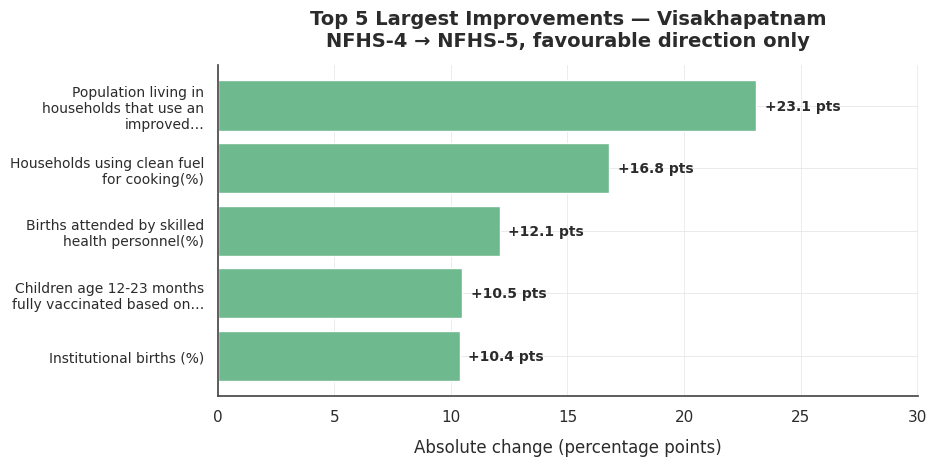

In [18]:

plot_df = top5_improvements.sort_values("absolute_change")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.barh(plot_df["indicator_short_label"], plot_df["absolute_change"], color=COLOR_IMPROVE)
ax.set_yticklabels([wrap_label(l, 30) for l in plot_df["indicator_short_label"]], fontsize=10)
for bar, val in zip(bars, plot_df["absolute_change"]):
    ax.annotate(f"+{val:.1f} pts", (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=10, fontweight="bold")
ax.set_title(f"Top 5 Largest Improvements — {TARGET_DISTRICT}\nNFHS-4 → NFHS-5, favourable direction only", pad=14)
ax.set_xlabel("Absolute change (percentage points)")
ax.set_xlim(0, plot_df["absolute_change"].max() * 1.3)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


**Interpretation:** Sanitation access and clean cooking fuel show the largest favourable gains — plausibly tied to household infrastructure delivery, though not proven here.


### 9.2 Largest Declines

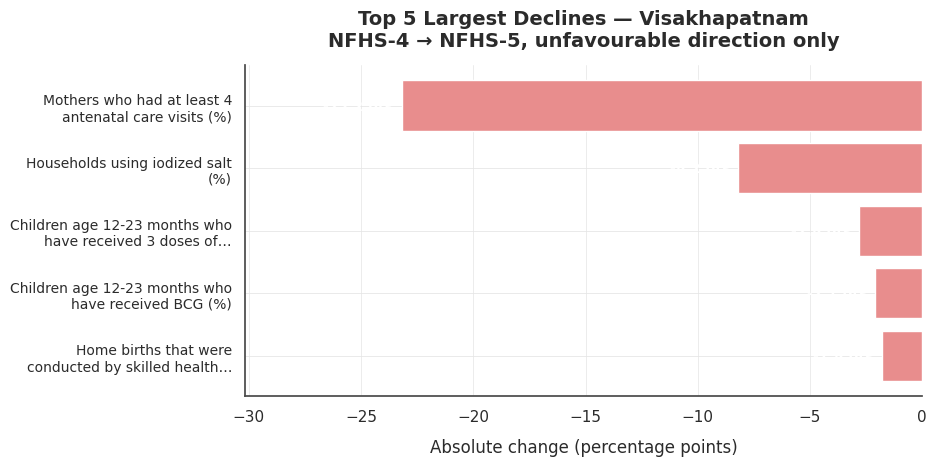

In [19]:

plot_df = top5_declines.sort_values("absolute_change", ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.barh(plot_df["indicator_short_label"], plot_df["absolute_change"], color=COLOR_DECLINE)
ax.set_yticklabels([wrap_label(l, 30) for l in plot_df["indicator_short_label"]], fontsize=10)
for bar, val in zip(bars, plot_df["absolute_change"]):
    ax.annotate(f"{val:.1f} pts", (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(-6, 0), textcoords="offset points", va="center", ha="right", fontsize=10, fontweight="bold", color="white")
ax.set_title(f"Top 5 Largest Declines — {TARGET_DISTRICT}\nNFHS-4 → NFHS-5, unfavourable direction only", pad=14)
ax.set_xlabel("Absolute change (percentage points)")
ax.set_xlim(plot_df["absolute_change"].min() * 1.3, 0)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


**Interpretation:** The 23-point drop in mothers receiving 4+ antenatal care visits is the single largest concern in this dataset and warrants follow-up.


### 9.3 Theme-Wise Comparison — Median Percentage Change

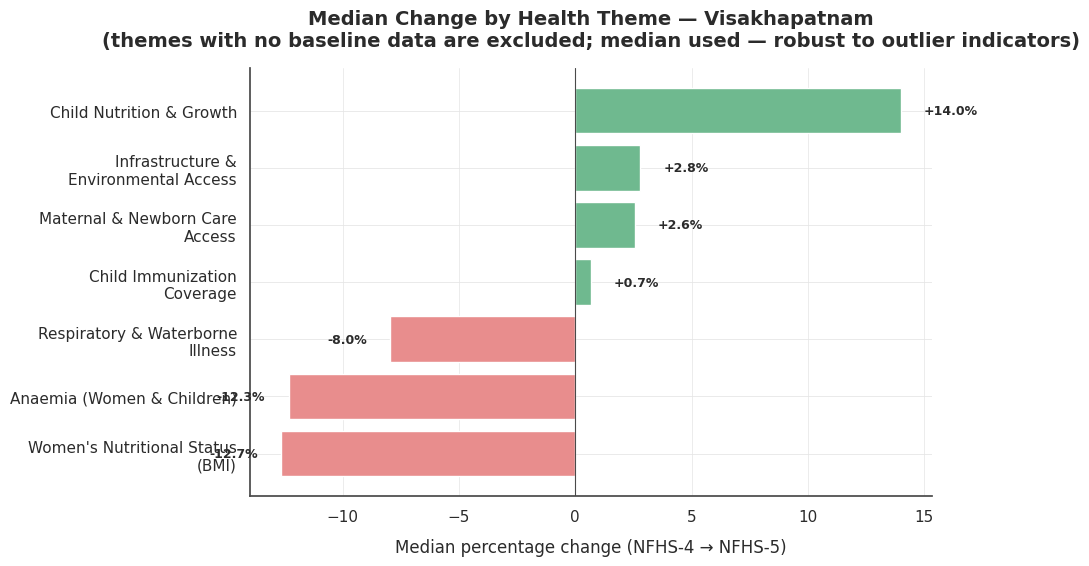

In [20]:

theme_change = (
    with_baseline.groupby("theme")["percentage_change"]
    .median()   # median instead of mean — robust to the extreme outlier(s) in the data
    .sort_values()
)
colors = [COLOR_DECLINE if v < 0 else COLOR_IMPROVE for v in theme_change.values]

fig, ax = plt.subplots(figsize=(10, 5.8))
bars = ax.barh([wrap_label(t, 26) for t in theme_change.index], theme_change.values, color=colors)
ax.axvline(0, color="#4a4a4a", linewidth=0.8)
for bar, val in zip(bars, theme_change.values):
    offset = 1 if val >= 0 else -1
    ha = "left" if val >= 0 else "right"
    ax.annotate(f"{val:+.1f}%", (bar.get_width() + offset, bar.get_y() + bar.get_height()/2),
                va="center", ha=ha, fontsize=9, fontweight="bold")
ax.set_xlabel("Median percentage change (NFHS-4 → NFHS-5)")
ax.set_title(f"Median Change by Health Theme — {TARGET_DISTRICT}\n(themes with no baseline data are excluded; median used — robust to outlier indicators)", pad=16)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


**Interpretation:** Themes well above zero show broad-based improvement; themes near or below zero deserve a closer, indicator-by-indicator look, since a theme average (or median) can hide one steep decline offsetting several small gains.


### 9.4 Heatmap — Percentage Change by Indicator, Grouped by Theme

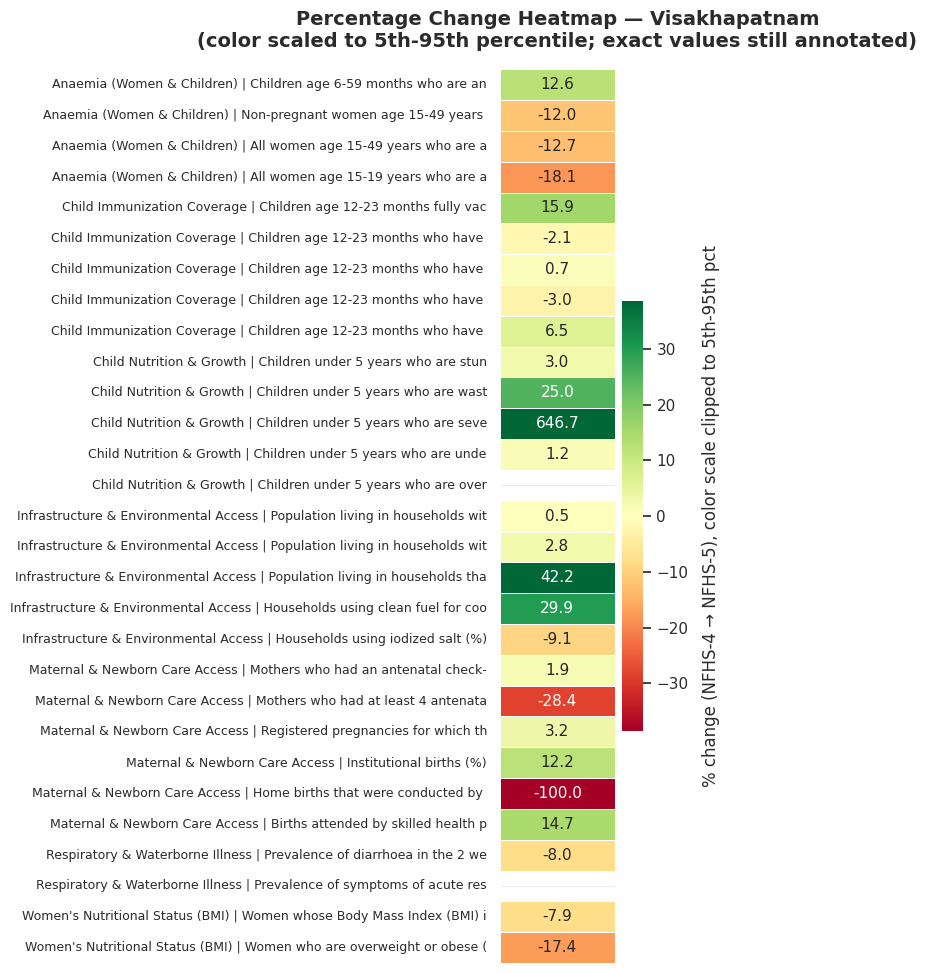

In [21]:

heatmap_df = with_baseline.sort_values(["theme", "indicator_number"]).copy()
heatmap_df["label"] = heatmap_df["theme"] + " | " + heatmap_df["indicator_short_label"].str.slice(0, 35)

# Percentile clipping for the COLOR SCALE only — underlying data and the
# printed annotations are untouched, so outliers are still shown exactly.
vals = heatmap_df["percentage_change"]
lo, hi = vals.quantile(0.05), vals.quantile(0.95)
vbound = max(abs(lo), abs(hi))  # symmetric around 0 so the diverging cmap stays meaningful

fig, ax = plt.subplots(figsize=(7, max(6, len(heatmap_df) * 0.34)))
data = heatmap_df.set_index("label")[["percentage_change"]]
sns.heatmap(
    data, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
    vmin=-vbound, vmax=vbound,
    cbar_kws={"label": "% change (NFHS-4 → NFHS-5), color scale clipped to 5th-95th pct"},
    linewidths=0.6, linecolor="white", ax=ax
)
ax.set_title(f"Percentage Change Heatmap — {TARGET_DISTRICT}\n(color scaled to 5th-95th percentile; exact values still annotated)", pad=16)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()


**Interpretation:** Red flags a numerically negative change — but for some indicators (e.g. disease burden) a negative change is actually favourable, so read colour alongside the Trend column, not in isolation.


### 9.5 Summary Dashboard

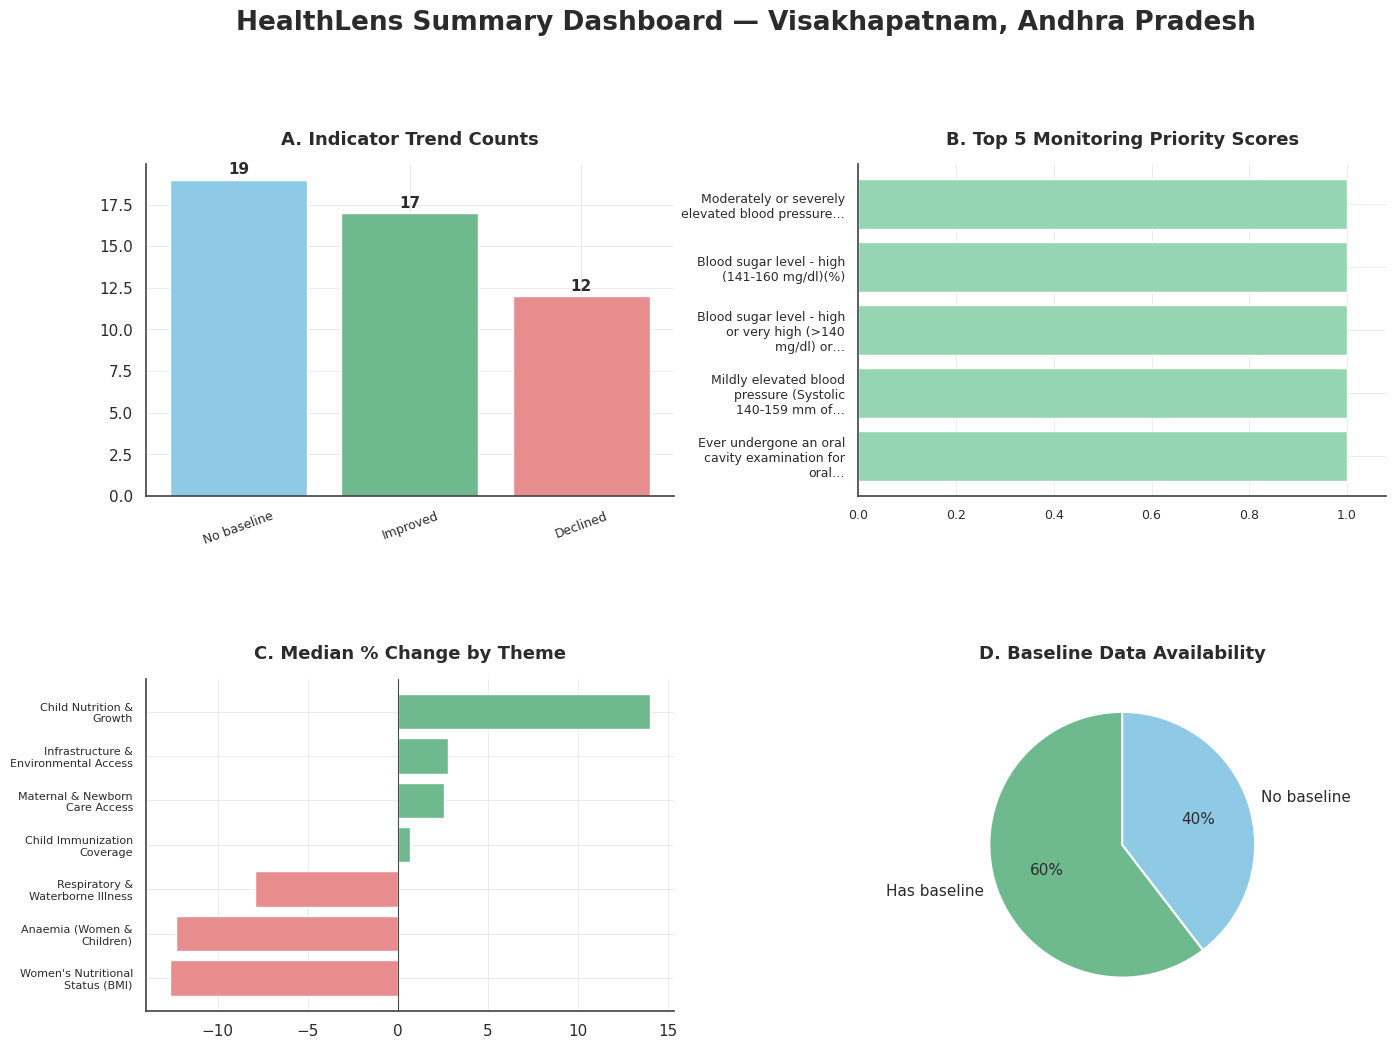

In [22]:

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, hspace=0.55, wspace=0.35)

# Panel A: trend counts
ax1 = fig.add_subplot(gs[0, 0])
trend_counts = analysis_table["trend"].value_counts()
trend_colors = {"Improved": COLOR_IMPROVE, "Declined": COLOR_DECLINE, "No baseline": COLOR_NEUTRAL,
                 "No change": "#cccccc", "Increased": PASTEL_PALETTE[2], "Decreased": PASTEL_PALETTE[4]}
bars = ax1.bar(trend_counts.index, trend_counts.values,
               color=[trend_colors.get(t, "#999999") for t in trend_counts.index])
for bar in bars:
    ax1.annotate(f"{int(bar.get_height())}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords="offset points", ha="center", fontsize=11, fontweight="bold")
ax1.set_title("A. Indicator Trend Counts", fontsize=13, fontweight="bold")
ax1.tick_params(axis="x", rotation=20, labelsize=9)
style_ax(ax1, grid_axis="y")

# Panel B: top 5 priority scores (now meaningfully differentiated)
ax2 = fig.add_subplot(gs[0, 1])
top_priority = health_monitoring_priority_table.head(5).sort_values("priority_score")
ax2.barh([wrap_label(l, 24) for l in top_priority["indicator_short_label"]],
         top_priority["priority_score"], color=PASTEL_PALETTE[3])
ax2.set_title("B. Top 5 Monitoring Priority Scores", fontsize=13, fontweight="bold")
ax2.set_xlim(0, 1.08)
ax2.tick_params(labelsize=9)
style_ax(ax2, grid_axis="x")

# Panel C: theme-wise median change
ax3 = fig.add_subplot(gs[1, 0])
colors = [COLOR_DECLINE if v < 0 else COLOR_IMPROVE for v in theme_change.values]
ax3.barh([wrap_label(t, 20) for t in theme_change.index], theme_change.values, color=colors)
ax3.axvline(0, color="#4a4a4a", linewidth=0.8)
ax3.set_title("C. Median % Change by Theme", fontsize=13, fontweight="bold")
ax3.tick_params(axis="y", labelsize=8)
style_ax(ax3, grid_axis="x")

# Panel D: baseline availability
ax4 = fig.add_subplot(gs[1, 1])
availability_counts = clean_df["has_baseline"].value_counts().reindex([True, False], fill_value=0)
ax4.pie(availability_counts.values, labels=["Has baseline", "No baseline"],
        colors=[COLOR_IMPROVE, COLOR_NEUTRAL], autopct="%1.0f%%", startangle=90,
        textprops={"fontsize": 11},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax4.set_title("D. Baseline Data Availability", fontsize=13, fontweight="bold")

fig.suptitle(f"HealthLens Summary Dashboard — {TARGET_DISTRICT}, {TARGET_STATE}",
             fontsize=19, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])

import os
os.makedirs("/content" if Path("/content").exists() else ".", exist_ok=True)
_dash_dir = Path("/content") if Path("/content").exists() else Path(".")
plt.savefig(_dash_dir / "summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** One-glance summary: most indicators fall into a few clear buckets (favourable, unfavourable, no history yet), a handful need the closest attention, and roughly two-fifths of curated indicators have no historical comparison point yet.


## 10. Conclusions

**Improvements:** Sanitation access, clean cooking fuel, and institutional/skilled-attendant births show the clearest favourable movement.

**Concerns:** The sharpest decline is in mothers receiving 4+ antenatal care visits, alongside a rise in severe child wasting and a drop in iodized salt usage.

**Needs monitoring:** "Lifestyle-Related NCDs & Screening" and "Substance Use" have no NFHS-4 baseline at all — the clearest, most defensible recommendation here is to start tracking these now.

**Limitations:** Two survey rounds can't distinguish a real trend from noise or methodology differences; the Priority Score is a transparent heuristic, not a validated risk index; nothing in this notebook establishes causality.

---
> **This analysis identifies trends worthy of monitoring — it does not establish causality.**


In [23]:

OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path(".")

analysis_table.to_csv(OUTPUT_DIR / f"healthlens_analysis_table_{TARGET_DISTRICT.replace(' ', '_')}.csv", index=False)
health_monitoring_priority_table.to_csv(OUTPUT_DIR / f"healthlens_priority_scores_{TARGET_DISTRICT.replace(' ', '_')}.csv", index=False)

print("Exported CSV outputs:")
print(f" - healthlens_analysis_table_{TARGET_DISTRICT.replace(' ', '_')}.csv")
print(f" - healthlens_priority_scores_{TARGET_DISTRICT.replace(' ', '_')}.csv")


Exported CSV outputs:
 - healthlens_analysis_table_Visakhapatnam.csv
 - healthlens_priority_scores_Visakhapatnam.csv
